# **Registration of adjacent slices**

In [1]:
# import my_package.rectification as rectification
import SM2ST
import importlib
import pandas as pd
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# download from https://github.com/WanluLiuLab/SpatialMETA/blob/master/spatialmeta/data/zenodo_url.txt

In [2]:
st_path = "/home/llx/project/jupyternotebook/SpatialMETA-master/spatialmeta_tutorial/data/adata_ST_Y7_T_raw.h5ad"
sm_path = "/home/llx/project/jupyternotebook/SpatialMETA-master/spatialmeta_tutorial/data/Y7_T_adata_SM_raw.h5ad"

In [3]:
import scanpy as sc
adata_SM_aligned = sc.read_h5ad("/home/llx/project/MSI_data/adata_SM_Y7_T_raw.aligned.h5ad")
adata_SM = sc.read_h5ad(sm_path)
adata_ST = sc.read_h5ad(st_path)

In [4]:
adata_SM

AnnData object with n_obs × n_vars = 10649 × 1299
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index'
    var: 'name', 'type'
    obsm: 'spatial'

In [5]:
adata_SM

AnnData object with n_obs × n_vars = 10649 × 1299
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index'
    var: 'name', 'type'
    obsm: 'spatial'

In [6]:
adata_SM_aligned

AnnData object with n_obs × n_vars = 10649 × 500
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index', 'total_intensity', 'mean_intensity'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'moranI', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_normalized', 'spatial_transformed'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [7]:
adata_SM

AnnData object with n_obs × n_vars = 10649 × 1299
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index'
    var: 'name', 'type'
    obsm: 'spatial'

In [8]:
adata_ST

AnnData object with n_obs × n_vars = 2018 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [9]:
adata_SM.obsm = adata_SM_aligned.obsm

In [10]:
# If data is available
adata_ST = sc.read_h5ad(st_path)

In [11]:
adata_SM

AnnData object with n_obs × n_vars = 10649 × 1299
    obs: 'x_coord_original', 'y_coord_original', 'total_intensity_pos', 'mean_intensity_pos', 'total_intensity_neg', 'mean_intensity_neg', 'spot_index'
    var: 'name', 'type'
    obsm: 'spatial', 'spatial_normalized', 'spatial_transformed'

In [12]:
name = 'Y7_T'
adata_SM.obsm['spatial'] = adata_SM.obsm['spatial_transformed']
adata_SM.uns['coord'] = adata_ST.obsm['spatial'] *adata_ST.uns['spatial'][name]['scalefactors']['tissue_hires_scalef']
adata_SM.obsm['spatial_transformed_scaled'] = adata_SM.obsm['spatial_transformed']/adata_ST.uns['spatial'][name]['scalefactors']['tissue_hires_scalef']
# adata_SM.obsm['spatial'] = adata_SM.obsm['spatial_transformed_scaled']
adata_SM.uns['spatial'] = adata_ST.uns['spatial']
adata_SM.uns['spatial']['Y7_T']['scalefactors']['tissue_hires_scalef'] = 1

In [13]:
adata_SM_o = adata_SM.copy()

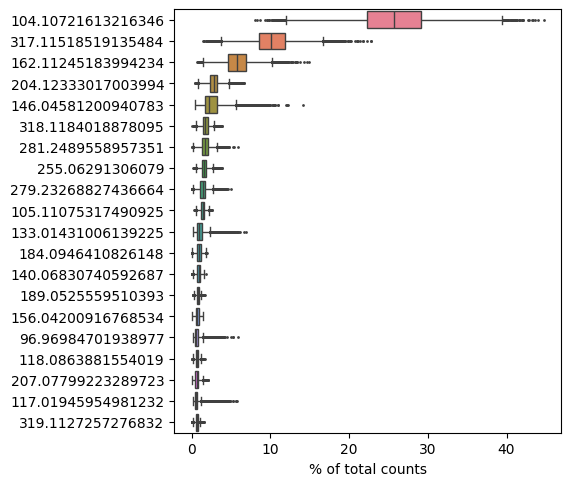

In [14]:
sc.pl.highest_expr_genes(adata_SM_o, n_top=20, )

In [15]:
adata_SM_o = adata_SM.copy()

In [16]:
import numpy as np
import scanpy as sc
from scipy.sparse import issparse
def X_baseline_corrected(adata):
    adata_SM = adata.copy()
    if issparse(adata_SM.X):
        X_input = adata_SM.X.A
    elif isinstance(adata_SM.X, np.ndarray):
        X_input = adata_SM.X
    else:
        X_input = np.array(adata_SM.X)
    X_dense = adata_SM.X.A  # to array
    
    # Column-wise baseline subtraction: Subtract the minimum value of each column from it.
    X_baseline_corrected = X_dense - X_dense.min(axis=0)
    # 
    adata_SM.layers['baseline_corrected'] = X_baseline_corrected
    adata_SM.X = adata_SM.layers['baseline_corrected']
    return adata_SM

In [17]:
adata_SM = X_baseline_corrected(adata_SM)

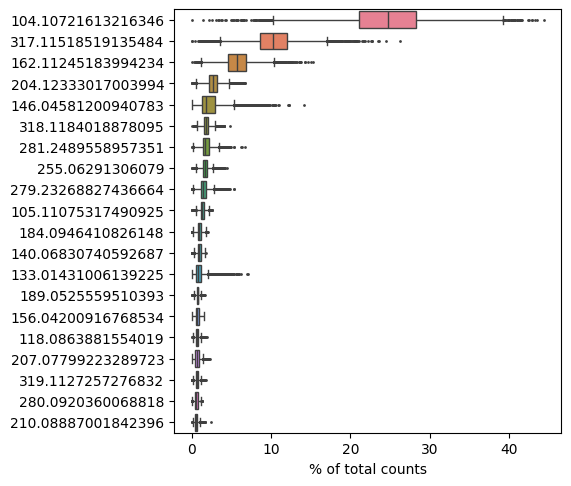

In [18]:
sc.pl.highest_expr_genes(adata_SM, n_top=20, )

In [19]:
sc.pp.normalize_total(adata_SM, target_sum=1e4)
sc.pp.log1p(adata_SM)

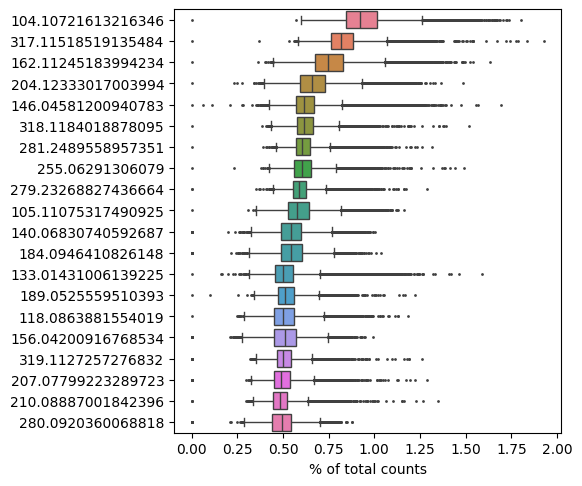

In [20]:
sc.pl.highest_expr_genes(adata_SM, n_top=20, )

<Axes: title={'center': '207.07799223289723'}, xlabel='spatial1', ylabel='spatial2'>

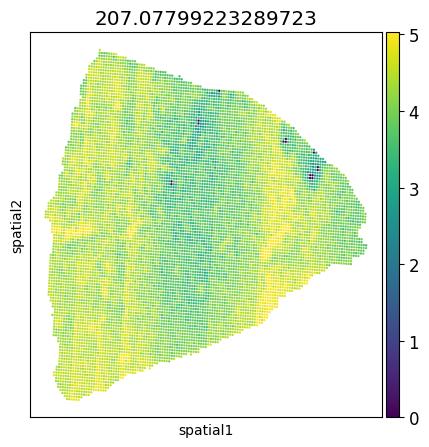

In [21]:
plot_gene = '207.07799223289723'#
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata_SM, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': 'TMSB10'}, xlabel='spatial1', ylabel='spatial2'>

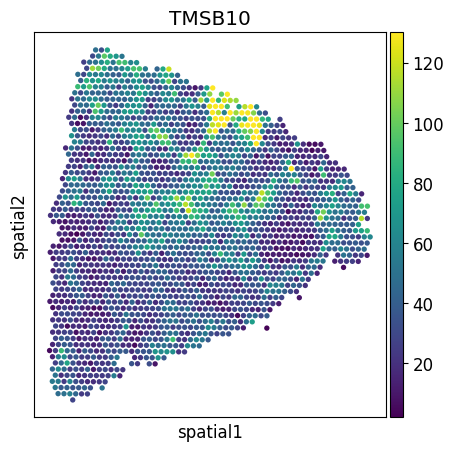

In [22]:
plot_gene = 'TMSB10'#
fig, ax = plt.subplots(figsize=(5, 5))  # 
plt.rcParams['font.size'] = 12  # 
sc.pl.embedding(adata_ST, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

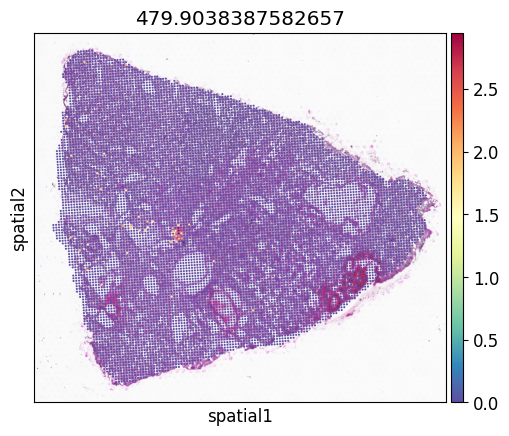

In [23]:
sc.pl.spatial(adata_SM, 
              img_key="hires", 
              color=['479.9038387582657'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.03,
              spot_size=None,
              bw=False, 
              alpha_img=1)#color是一个感兴趣的基因的list

## **SM2ST result**

In [1]:
import SM2ST
adata_SMLED = SM2ST.train_SMLED(adata=adata_SM, keep_ratio=0., coord_sf=2.0, train_epoch=10000, experiment='generation', WMMSE=1.0)

In [ ]:
plot_gene = '207.07799223289723' #
fig, ax = plt.subplots(figsize=(5, 5))  # 例如，figsize=(10, 8) 表示宽度为
plt.rcParams['font.size'] = 12  # 假设默认字体大小是10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [ ]:
adata_SMLED.obsm['spatial'] = adata_SM.uns['coord']

In [ ]:
adata_SMLED.uns['spatial'] = adata_SM.uns['spatial']
adata_SMLED.obsm['spatial_scalefactors'] = adata_SMLED.obsm['spatial']

In [ ]:
# adata_SMLED.obsm['spatial'] = adata_SMLED.obsm['spatial_scalefactors']

In [ ]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['207.07799223289723'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.07,
              spot_size=None,
              bw=False, 
              alpha_img=1)#color是一个感兴趣的基因的list

In [34]:
# adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/SpatialMETA-master/spatialmeta_tutorial/data/Y7_T_adata_SMLED_test_Tweedie1.h5ad')

In [24]:
adata_SMLED = sc.read_h5ad('/home/llx/project/jupyternotebook/SpatialMETA-master/spatialmeta_tutorial/data/Y7_T_adata_SMLED_test_Tweedie1.h5ad')

In [25]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_SMLED)
sq.gr.spatial_autocorr(adata_SMLED, mode="moran", genes=adata_SMLED.var_names)
sq.gr.spatial_autocorr(adata_SMLED, mode="geary", genes=adata_SMLED.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [26]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_SM)
sq.gr.spatial_autocorr(adata_SM, mode="moran", genes=adata_SM.var_names)
sq.gr.spatial_autocorr(adata_SM, mode="geary", genes=adata_SM.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 36 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 36 variables were constant, will return nan for these.
  warnings.warn(


In [27]:
ms_adata_high_moran_genes = adata_SM.uns['moranI']['I'][(adata_SM.uns['moranI']['I'] > 0.15) & (adata_SM.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = adata_SM[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = adata_SM.uns['gearyC']['C'][(adata_SM.uns['gearyC']['C'] < 0.7) & (adata_SM.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = adata_SM[:, ms_adata_high_geary_genes]

In [28]:
adata_SMLED_high_moran_genes = adata_SMLED.uns['moranI']['I'][(adata_SMLED.uns['moranI']['I'] > 0.15) & (adata_SMLED.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_SMLED[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_SMLED.uns['gearyC']['C'][(adata_SMLED.uns['gearyC']['C'] < 0.7) & (adata_SMLED.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_SMLED[:, adata_SMLED_high_geary_genes]

In [29]:
ms_adata_set1 = set(ms_adata_high_geary.var_names)
ms_adata_set2 = set(ms_adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

In [30]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

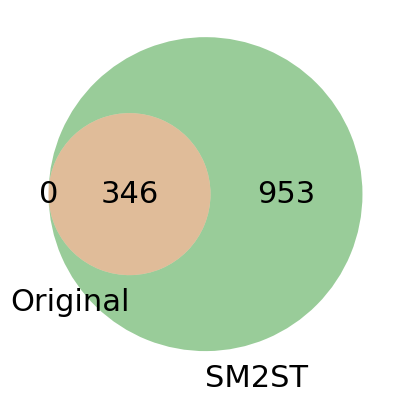

In [31]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# 
set1 = ms_adata_v
set2 = adata_SMLED_v

# 
venn = venn2([set1, set2], ('Original', 'SM2ST'))

# 
venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')

# 
venn.get_label_by_id('100').set_fontsize(22)
venn.get_label_by_id('010').set_fontsize(22)
venn.get_label_by_id('110').set_fontsize(22)

# 
venn.get_label_by_id('A').set_fontsize(22)  # 
venn.get_label_by_id('B').set_fontsize(22)  #
# 
plt.show()

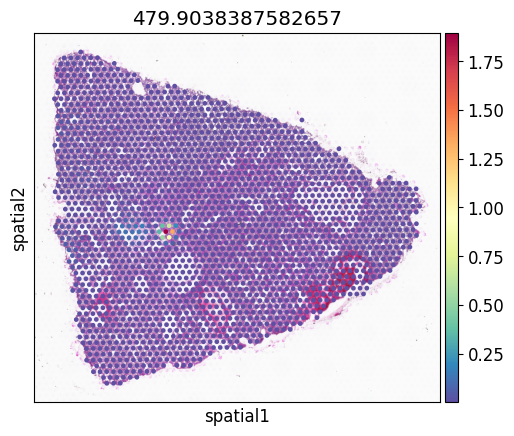

In [32]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['479.9038387582657'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.07,
              spot_size=None,
              bw=False, 
              alpha_img=1)

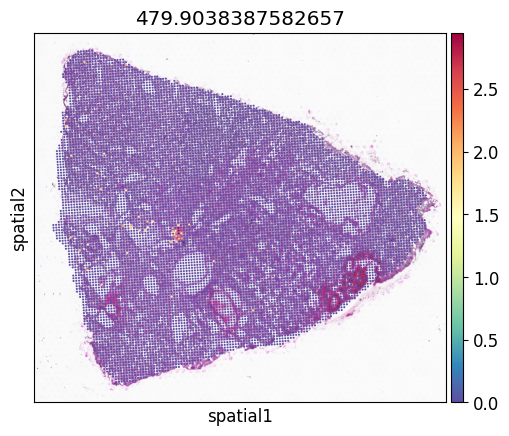

In [33]:
sc.pl.spatial(adata_SM, 
              img_key="hires", 
              color=['479.9038387582657'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.03,
              spot_size=None,
              bw=False, 
              alpha_img=1)

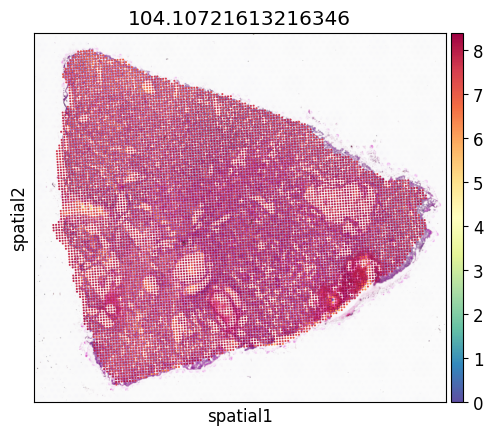

In [34]:
sc.pl.spatial(adata_SM, 
              img_key="hires", 
              color=['104.10721613216346'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.03,
              spot_size=None,
              bw=False, 
              alpha_img=1)

## **SpatialMETA result**

In [35]:
adata_SM_new = sc.read_h5ad('/home/llx/project/jupyternotebook/SpatialMETA-master/spatialmeta_tutorial/data/Y7_T_adata_SM_raw_reassign.h5ad')

In [36]:
sc.pp.normalize_total(adata_SM_new, target_sum=1e4)
sc.pp.log1p(adata_SM_new)
import squidpy as sq
sq.gr.spatial_neighbors(adata_SM_new)
sq.gr.spatial_autocorr(adata_SM_new, mode="moran", genes=adata_SM_new.var_names)
sq.gr.spatial_autocorr(adata_SM_new, mode="geary", genes=adata_SM_new.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 45 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 45 variables were constant, will return nan for these.
  warnings.warn(


In [37]:
adata_SM_new_high_moran_genes = adata_SM_new.uns['moranI']['I'][(adata_SM_new.uns['moranI']['I'] > 0.15) & (adata_SM_new.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SM_new_high_moran = adata_SM_new[:, adata_SM_new_high_moran_genes]

adata_SM_new_high_geary_genes = adata_SM_new.uns['gearyC']['C'][(adata_SM_new.uns['gearyC']['C'] < 0.7) & (adata_SM_new.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SM_new_high_geary = adata_SM_new[:, adata_SM_new_high_geary_genes]

In [38]:
adata_SM_new_set1 = set(adata_SM_new_high_geary.var_names)
adata_SM_new_set2 = set(adata_SM_new_high_moran.var_names)
adata_SM_new_v = adata_SM_new_set1&adata_SM_new_set2

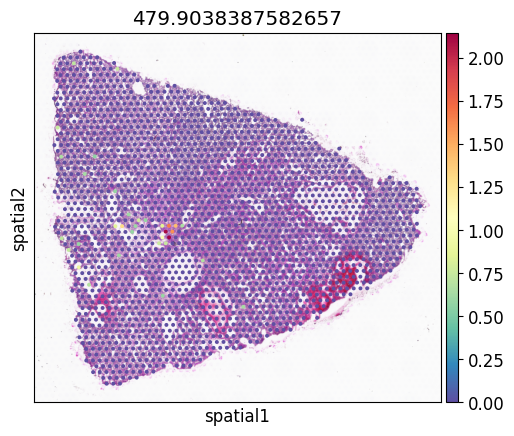

In [39]:
sc.pl.spatial(adata_SM_new, 
              img_key="hires", 
              color=['479.9038387582657'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.9,
              spot_size=None,
              bw=False, 
              alpha_img=1)

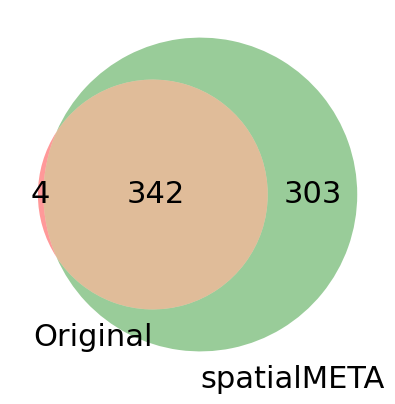

In [41]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


set1 = ms_adata_v
set2 = adata_SM_new_v


venn = venn2([set1, set2], ('Original', 'spatialMETA'))

venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')

venn.get_label_by_id('100').set_fontsize(22)
venn.get_label_by_id('010').set_fontsize(22)
venn.get_label_by_id('110').set_fontsize(22)

venn.get_label_by_id('A').set_fontsize(22)
venn.get_label_by_id('B').set_fontsize(22) 

plt.show()

In [42]:
set1 -set2

{'632.9844083206727',
 '688.3515765378075',
 '754.3906651160707',
 '776.4039661244722'}

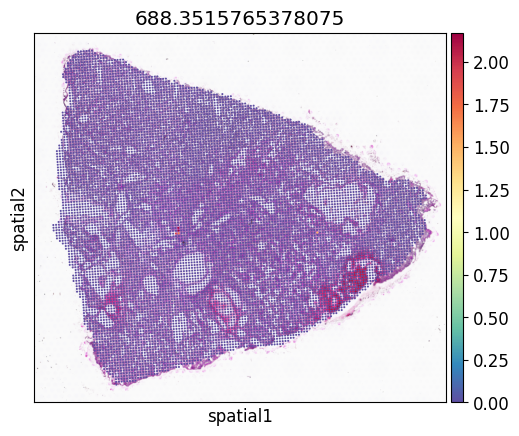

In [53]:
sc.pl.spatial(adata_SM, 
              img_key="hires", 
              color=['688.3515765378075'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.03,
              spot_size=None,
              bw=False, 
              alpha_img=1)

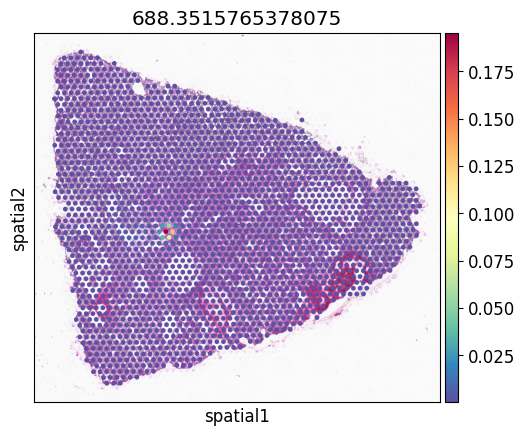

In [52]:
sc.pl.spatial(adata_SMLED, 
              img_key="hires", 
              color=['688.3515765378075'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.07,
              spot_size=None,
              bw=False, 
              alpha_img=1)

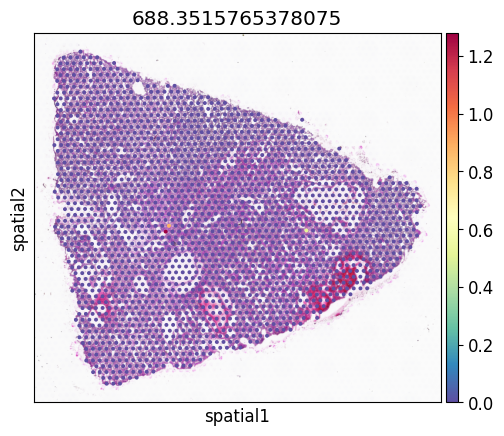

In [51]:
sc.pl.spatial(adata_SM_new, 
              img_key="hires", 
              color=['688.3515765378075'], 
              cmap='Spectral_r', 
              ncols=3,
              img=None, 
              size=0.9,
              spot_size=None,
              bw=False, 
              alpha_img=1)

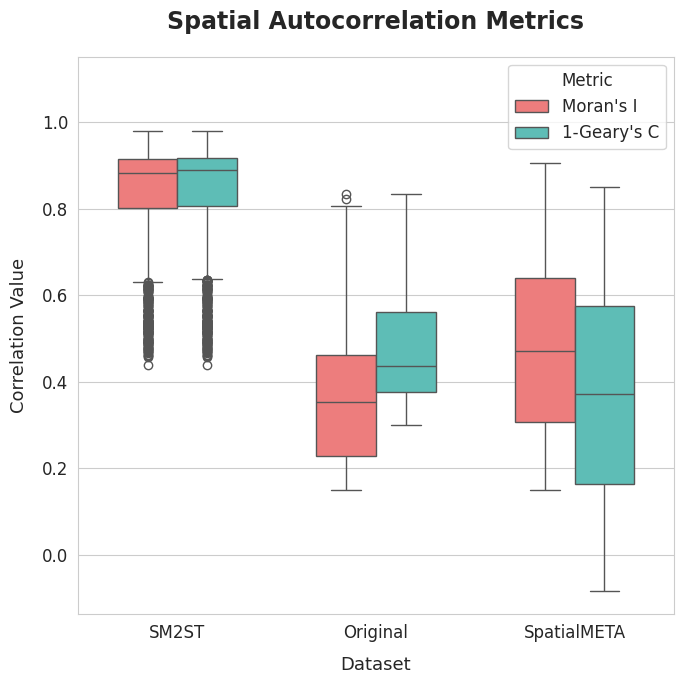

=== 数据统计摘要 ===
SM2ST - Moran's I: n=1299, median=0.884
SM2ST - 1-Geary's C: n=1299, median=0.889
Original - Moran's I: n=573, median=0.353
Original - 1-Geary's C: n=346, median=0.436
SpatialMETA - Moran's I: n=870, median=0.471
SpatialMETA - 1-Geary's C: n=1112, median=0.371


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 数据准备
# 提取并转换数据（注意spatialMETA的gearyC筛选条件不同）
moranI_SM2ST = adata_SMLED.uns['moranI']['I'][
    (adata_SMLED.uns['moranI']['I'] > 0.15) & 
    (adata_SMLED.uns['moranI']['pval_norm'] < 0.05)
]
gearyC_SM2ST = 1 - adata_SMLED.uns['gearyC']['C'][
    (adata_SMLED.uns['gearyC']['C'] < 0.7) & 
    (adata_SMLED.uns['gearyC']['pval_norm'] < 0.05)
]

moranI_original = adata_SM.uns['moranI']['I'][
    (adata_SM.uns['moranI']['I'] > 0.15) & 
    (adata_SM.uns['moranI']['pval_norm'] < 0.05)
]
gearyC_original = 1 - adata_SM.uns['gearyC']['C'][
    (adata_SM.uns['gearyC']['C'] < 0.7) & 
    (adata_SM.uns['gearyC']['pval_norm'] < 0.05)
]

moranI_spatialMETA = adata_SM_new.uns['moranI']['I'][
    (adata_SM_new.uns['moranI']['I'] > 0.15) & 
    (adata_SM_new.uns['moranI']['pval_norm'] < 0.05)
]
gearyC_spatialMETA = 1 - adata_SM_new.uns['gearyC']['C'][
    (adata_SM_new.uns['gearyC']['C'] > 0.15) & 
    (adata_SM_new.uns['gearyC']['pval_norm'] < 0.05)
]

# 创建长格式DataFrame
data_list = []
data_configs = [
    ('SM2ST', 'Moran\'s I', moranI_SM2ST),
    ('SM2ST', '1-Geary\'s C', gearyC_SM2ST),
    ('Original', 'Moran\'s I', moranI_original),
    ('Original', '1-Geary\'s C', gearyC_original),
    ('SpatialMETA', 'Moran\'s I', moranI_spatialMETA),
    ('SpatialMETA', '1-Geary\'s C', gearyC_spatialMETA)
]

for dataset, metric, values in data_configs:
    if len(values) > 0:  # 确保非空
        data_list.extend([{
            'Dataset': dataset,
            'Metric': metric,
            'Value': val
        } for val in values])

df = pd.DataFrame(data_list)

# 2. 绘图
plt.figure(figsize=(7, 7))
sns.set_style("whitegrid")

# 定义颜色映射：Moran's I用暖色，Geary's C用冷色
colors = {'Moran\'s I': '#FF6B6B', '1-Geary\'s C': '#4ECDC4'}

# 创建箱线图
ax = sns.boxplot(
    data=df,
    x='Dataset',
    y='Value',
    hue='Metric',
    palette=colors,
    width=0.6,
    showfliers=True,
    dodge=True  # 并排显示
)

# # 添加抖动散点
# sns.stripplot(
#     data=df,
#     x='Dataset',
#     y='Value',
#     hue='Metric',
#     dodge=True,
#     color='black',
#     alpha=0.3,
#     size=3,
#     jitter=True,
#     ax=ax,
#     legend=False
# )

# 3. 图形美化
plt.title('Spatial Autocorrelation Metrics', 
          fontsize=17, fontweight='bold', pad=20)
plt.xlabel('Dataset', fontsize=13, labelpad=10)
plt.ylabel('Correlation Value', fontsize=13, labelpad=10)

# 4. 添加统计信息
datasets = ['SM2ST', 'Original', 'SpatialMETA']
metrics = ['Moran\'s I', '1-Geary\'s C']
y_offset = df['Value'].max() * 0.02  # 动态计算标注位置偏移

# for i, dataset in enumerate(datasets):
#     for j, metric in enumerate(metrics):
#         values = df[(df['Dataset'] == dataset) & (df['Metric'] == metric)]['Value']
#         if len(values) > 0:
#             median_val = values.median()
#             n_obs = len(values)
#             # 计算箱体中心位置
#             x_pos = i + (j - 0.5) * 0.4
#             plt.text(
#                 x_pos, median_val + y_offset,
#                 f'n={n_obs}\nmed={median_val:.3f}',
#                 ha='center', va='bottom',
#                 fontsize=9,
#                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
#                          edgecolor='lightgray', alpha=0.9)
#             )

# # 5. 添加阈值参考线
# plt.axhline(y=0.15, color='gray', linestyle='--', alpha=0.5, 
#            label='MoranI threshold (>0.15)')

# # 添加图例
# plt.legend(title='Metric', loc='upper right', bbox_to_anchor=(1.15, 1), 
#           fontsize=10, title_fontsize=11)

# 设置Y轴范围以确保文本可见
y_min, y_max = plt.ylim()
plt.ylim(y_min, y_max + (y_max - y_min) * 0.1)

plt.tight_layout()
plt.show()

# 6. 打印统计摘要
print("=== 数据统计摘要 ===")
for dataset, metric, values in data_configs:
    if len(values) > 0:
        print(f"{dataset} - {metric}: n={len(values)}, median={np.median(values):.3f}")

In [57]:
ms_adata_va = adata_SM[:,list(ms_adata_v)]
adata_SM_new_va = adata_SM_new[:,list(ms_adata_v)]
ms_column_sums = np.sum(ms_adata_va.X, axis=0)

ms_m = adata_SM.X.shape[0]
ms_column_means = ms_column_sums / ms_m
adata_SM_new_column_sums = np.sum(adata_SM_new_va.X.A, axis=0)

adata_SM_new_m = adata_SM_new.X.A.shape[0]
adata_SM_new_column_means = adata_SM_new_column_sums / adata_SM_new_m

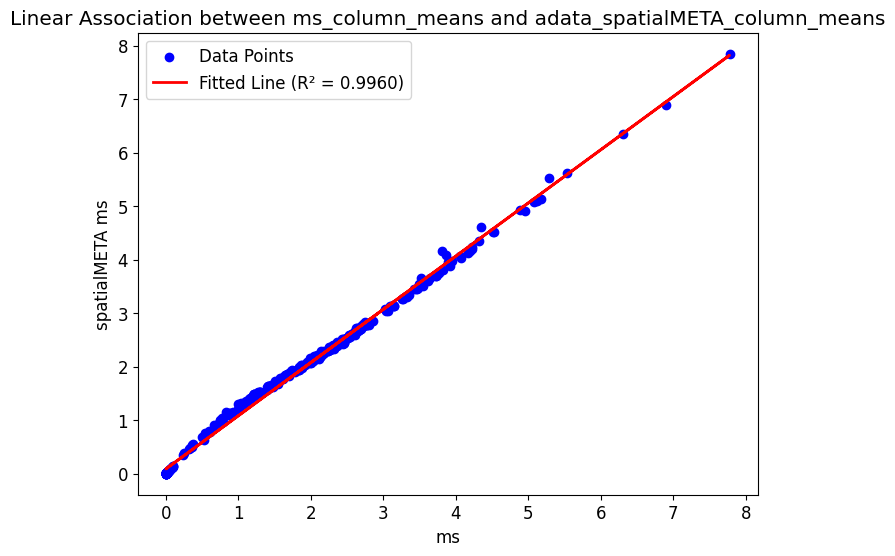

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = ms_column_means.reshape(-1, 1)  # 将 ms_column_means 转换为列向量
y = adata_SM_new_column_means


model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted Line (R² = {r2:.4f})') 
plt.xlabel('ms')
plt.ylabel('spatialMETA ms')
plt.title('Linear Association between ms_column_means and adata_spatialMETA_column_means')
plt.legend()
# plt.grid(True)
plt.show()

In [54]:
ms_adata_va = adata_SM[:,list(ms_adata_v)]
adata_SMLED_va = adata_SMLED[:,list(ms_adata_v)]
ms_column_sums = np.sum(ms_adata_va.X, axis=0)

ms_m = adata_SM.X.shape[0]
ms_column_means = ms_column_sums / ms_m
SMLED_column_sums = np.sum(adata_SMLED_va.X.A, axis=0)

SMLED_m = adata_SMLED.X.A.shape[0]
SMLED_column_means = SMLED_column_sums / SMLED_m

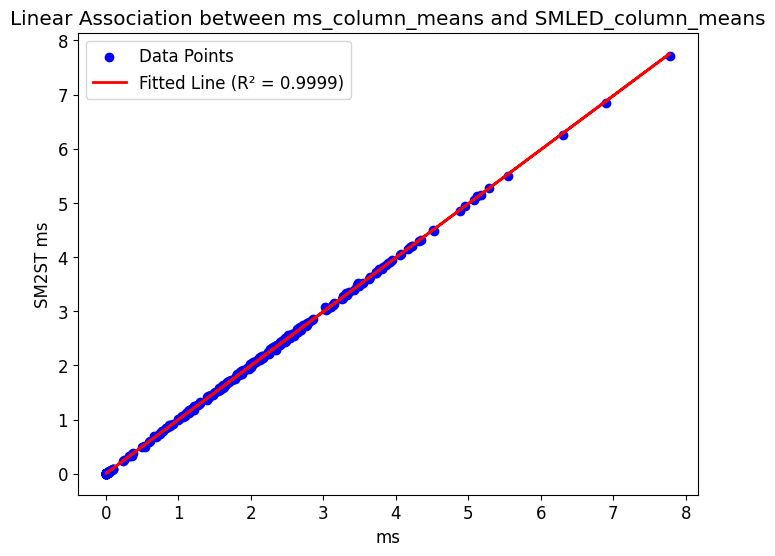

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = ms_column_means.reshape(-1, 1)
y = SMLED_column_means
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)


plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data Points') 
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted Line (R² = {r2:.4f})')
plt.xlabel('ms')
plt.ylabel('SM2ST ms')
plt.title('Linear Association between ms_column_means and SMLED_column_means')
plt.legend()
# plt.grid(True)
plt.show()